# Import and functions 

In [ ]:
from Utilities.utils import *
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy
from scipy.signal import butter
from scipy.signal import filtfilt
import re
import h5py

# new way based on Kime t al Ganguly
def butter_bandpass_filter(data, lowcut, highcut, fs, order_hp, order_lp):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist

    # High-pass filtering
    b_hp, a_hp = butter(order_hp, low, btype='high', analog=False)
    filtered_hp = filtfilt(b_hp, a_hp, data)

    # Low-pass filtering
    b_lp, a_lp = butter(order_lp, high, btype='low', analog=False)
    filtered_band = filtfilt(b_lp, a_lp, filtered_hp)

    return filtered_band

def extract_number(filename):
    """Extracts the numerical part from the filename."""
    match = re.search(r'channel-(\d+)', filename)
    if match:
        return int(match.group(1))
    return float('inf')  # Return infinity if no number is found



chose which channels to keep - exclude noisy channels

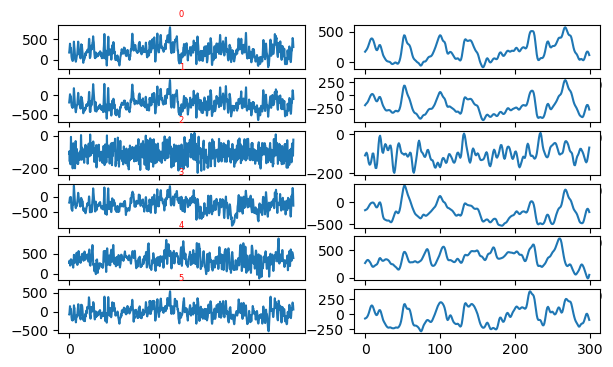

In [7]:
# Load in the short example raw data (full raw data not included to save space)
current_working_dir = os.path.join(Path(os.getcwd()).parent,'data') + r'\preproc\Sleep\LFP\\'

with h5py.File(current_working_dir + "example_short_raw_LFP_data.h5", "r") as f:
    example_short_data = [f[f"array_{i}"][:] for i in range(len(f))]
    
## chose which channels to keep 
fig, axs = plt.subplots(len(example_short_data), 2, figsize=(7, 4))  # 2 rows, 1 column
for i,dat in enumerate(example_short_data):
    #downsample just for visualisation
    dat = dat[::10]
    axs[i][0].plot(dat)
    axs[i][1].plot(dat[0:300])
    axs[i][0].set_title(f"{i}", fontsize=6, color = 'red')

Text(0.5, 1.0, 'Average LFP')

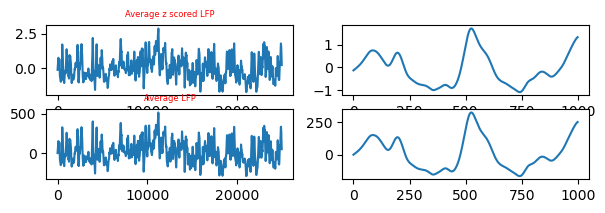

In [8]:
### choose channels 
chosen_channels_bool = [1,1,0,1,1,1]

channel_z = []
channel_ = []
for ind,dat in enumerate(example_short_data):
    if chosen_channels_bool[ind] == 1:
        channel_z += [scipy.stats.zscore(dat)]
        channel_ += [dat]
lfp_all_z = np.vstack(channel_z) 
lfp_all = np.vstack(channel_)     
# Avg all channels
average_lfp_z = lfp_all_z.mean(axis=0) # AVG
average_lfp = lfp_all.mean(axis=0) # AVG

fig, axs = plt.subplots(2, 2, figsize=(7, 2))  # 2 rows, 1 column
axs[0][0].plot(average_lfp_z)
axs[0][1].plot(average_lfp_z[:1000])
axs[0][0].set_title(f"Average z scored LFP", fontsize=6, color = 'red')

axs[1][0].plot(average_lfp)
axs[1][1].plot(average_lfp[:1000])
axs[1][0].set_title(f"Average LFP", fontsize=6, color = 'red')

delta bandpass 

Text(0.5, 1.0, 'Average z scored delta band pass')

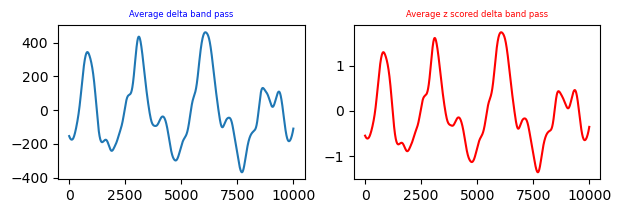

In [9]:
# Load in the full averaged data 
average_lfp = np.load(current_working_dir + 'average_lfp.npy')
average_lfp_z = np.load(current_working_dir + 'average_lfp_zscored.npy')

#### filter for delta band:
fs = 2500  # Sampling frequency
lowcut = 0.5  # Cutoff frequency for high-pass filter (Hz)
highcut = 4   # Cutoff frequency for low-pass filter (Hz)
order_hp = 2  # Order of the high-pass Butterworth filter
order_lp = 2  # Order of the low-pass Butterworth filter
delta_filtered_z = butter_bandpass_filter(average_lfp_z, lowcut, highcut, fs, order_hp, order_lp) 
delta_filtered = butter_bandpass_filter(average_lfp, lowcut, highcut, fs, order_hp, order_lp) 

fig, axs = plt.subplots(1, 2, figsize=(7, 2))  # 2 rows, 1 column
axs[0].plot(delta_filtered[10000:20000])
axs[0].set_title(f"Average delta band pass", fontsize=6, color = 'blue')
axs[1].plot(delta_filtered_z[10000:20000], color = 'red')
axs[1].set_title(f"Average z scored delta band pass", fontsize=6, color = 'red')

Text(0.5, 1.0, 'Average z spindle band pass')

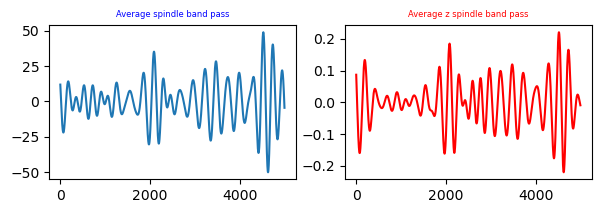

In [10]:
#The LFP average was filtered in spindle band (10-14 Hz) through two independent filtering; 
#the high pass Butterworth filter (6th order, zero phase shifted, with a cutoff at 10 Hz) was applied and 
#then followed by the low pass Butterworth filter (8th order, zero phase shifted, with a cutoff at 14Hz).
lowcut = 9  # Cutoff frequency for high-pass filter (Hz)
highcut = 14   # Cutoff frequency for low-pass filter (Hz)
order_hp = 6  # Order of the high-pass Butterworth filter
order_lp = 8  # Order of the low-pass Butterworth filter

spindle_filtered = butter_bandpass_filter(average_lfp, lowcut, highcut, fs, order_hp, order_lp) # crop for plotting
spindle_filtered_z = butter_bandpass_filter(average_lfp_z, lowcut, highcut, fs, order_hp, order_lp) # crop for plotting

fig, axs = plt.subplots(1, 2, figsize=(7, 2))  # 2 rows, 1 column
axs[0].plot(spindle_filtered[50000:55000])
axs[0].set_title(f"Average spindle band pass", fontsize=6, color = 'blue')
axs[1].plot(spindle_filtered_z[50000:55000], color = 'red')
axs[1].set_title(f"Average z spindle band pass", fontsize=6, color = 'red')
